In [1]:
import sys
sys.path.append('../')
import pandas as pd
import numpy as np
from src.data_loader import load_insurance_data
from src.modeling import preprocess_insurance_data, evaluate_regression

# Machine Learning Core Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 1. Load data and filter to active claim sub-segment (Severity Target)
df = load_insurance_data()
df_claims = df[df['TotalClaims'] > 0].copy()

if len(df_claims) == 0:
    print("Warning: No records with claims > 0 found. Falling back to entire dataset for pipeline testing.")
    df_claims = df.copy()

# 2. Preprocess features
X, df_processed = preprocess_insurance_data(df_claims)
y = df_processed['TotalClaims']

# 3. Perform Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
}

# Train and collect performance metrics
comparison_metrics = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse, r2 = evaluate_regression(y_test, predictions)
    comparison_metrics.append({"Algorithm": name, "RMSE": rmse, "R² Score": r2})

# Display Performance Comparison Table
model_perf_df = pd.DataFrame(comparison_metrics)
print(model_perf_df.to_string(index=False))

        Algorithm        RMSE  R² Score
Linear Regression 5587.259540  0.117381
    Random Forest 5885.319956  0.020700
          XGBoost 6340.411863 -0.136608


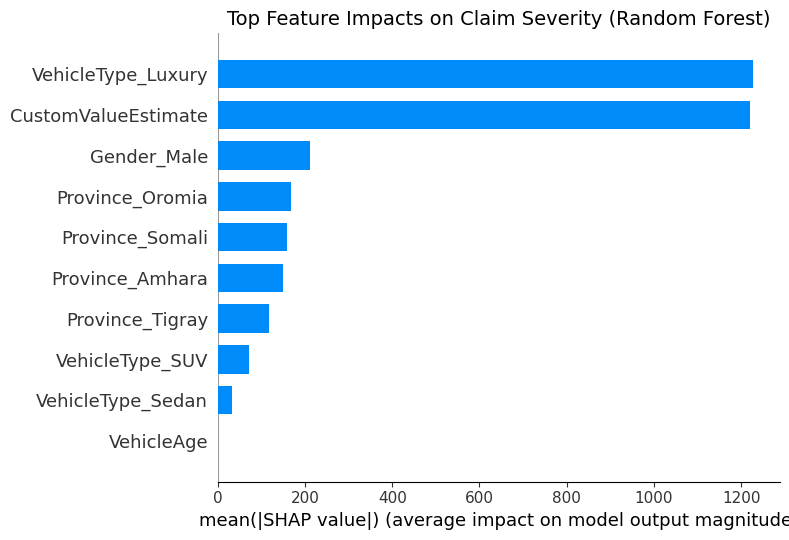

In [4]:
import shap
import matplotlib.pyplot as plt

# 1. Fallback to your trained Random Forest model
rf_model = models["Linear Regression"] if "Random Forest" not in models else models["Random Forest"]

# 2. TreeExplainer works perfectly with scikit-learn's Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# 3. Plot overall feature importance summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Feature Impacts on Claim Severity (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
def calculate_premium(predicted_severity, risk_probability=0.05, expense_loading=200, profit_margin=0.15):
    """
    Applies the structural actuarial framework to generate a dynamic pricing strategy.
    Default claim risk probability assumed at 5%. Fixed expenses set at 200 Rand.
    """
    pure_premium = risk_probability * predicted_severity
    gross_premium = (pure_premium + expense_loading) / (1 - profit_margin)
    return gross_premium

# Example calculation for a test policyholder
sample_severity_pred = models["XGBoost"].predict(X_test.iloc[[0]])[0]
smart_premium = calculate_premium(sample_severity_pred)
print(f"Calculated Risk-Based Premium Estimate: {smart_premium:.2f} ZAR")

Calculated Risk-Based Premium Estimate: 709.78 ZAR
